**Paso 1: Instalar MLflow**

In [ ]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import mlflow

print("MLflow instalado correctamente")
print("Version:", mlflow.__version__)

MLflow instalado correctamente
Version: 3.14.0


**Paso 2: Importar librerías**

In [ ]:
import mlflow
import mlflow.sklearn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Paso 3: Generar datos simulados


In [ ]:
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos cargados correctamente")

Datos cargados correctamente


In [ ]:
import pandas as pd

df_creditos = pd.DataFrame(X, columns=[
    "Edad",
    "Ingreso_Mensual",
    "Antiguedad_Laboral",
    "Score_Crediticio",
    "Deuda_Actual",
    "Numero_Creditos",
    "Historial_Pagos",
    "Monto_Solicitado",
    "Dependientes",
    "Ahorros"
])

df_creditos["Aprobacion"] = y

display(df_creditos.head(10))

,Edad,Ingreso_Mensual,Antiguedad_Laboral,Score_Crediticio,Deuda_Actual,Numero_Creditos,Historial_Pagos,Monto_Solicitado,Dependientes,Ahorros,Aprobacion
0,3.316690,-2.029674,2.355629,-0.215829,-1.419279,0.914109,-5.980685,1.518092,-0.042540,-3.397662,0
1,4.161930,-3.898558,0.174588,-0.091221,-1.360185,-0.606968,-4.648657,-2.454777,-0.667688,-0.629240,0
2,-0.477509,3.103860,2.694822,1.562327,4.191341,1.230190,3.491643,0.827346,0.635312,-2.593035,0
3,-1.894990,2.218811,-0.062834,-2.495924,-1.738007,-1.256467,-1.842087,1.668228,0.494795,-0.994083,0
4,-0.101203,0.444587,-0.793103,-2.204839,3.360553,0.922288,0.683308,-1.889515,-1.772399,1.312052,1
5,-0.497324,1.160589,-1.371626,0.132640,1.556043,2.848289,-0.275154,1.231785,-0.073907,-1.435493,0
6,3.786011,-1.291993,1.027079,0.907064,2.106804,-0.562708,-1.721881,2.511537,-0.276346,-3.193861,0
7,-2.998253,2.116089,0.080667,-0.371494,2.595255,0.375995,5.083844,0.657958,-0.407438,2.588078,1
8,-0.103251,-0.184583,0.603200,0.764342,-3.846012,-0.012996,-2.741570,-1.145605,-0.012714,-1.379041,0
9,3.085656,-2.415266,0.215140,-2.558883,0.609122,-0.837658,-4.086636,-3.214651,0.469214,0.146754,1


In [ ]:
print("Cantidad de registros:", df.shape[0])
print("Cantidad de variables:", df.shape[1] - 1)

print("\nDistribución de aprobaciones:")
print(df["Aprobacion"].value_counts())

Cantidad de registros: 5000
Cantidad de variables: 10

Distribución de aprobaciones:
Aprobacion
1    2503
0    2497
Name: count, dtype: int64


# Paso 4: Entrenar el modelo


In [ ]:
with mlflow.start_run():

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    mlflow.sklearn.log_model(
        model,
        "random_forest_model"
    )

    print("Accuracy:", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1 Score:", round(f1,4))

2026/07/20 03:34:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/20 03:34:09 INFO mlflow.store.db.utils: Updating database tables
2026/07/20 03:34:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.921
Precision: 0.9264
Recall: 0.9133
F1 Score: 0.9198


# Paso 5: Simulación de alertas


In [ ]:
accuracy_actual = accuracy

if accuracy_actual < 0.85:
    print("ALERTA: Accuracy por debajo del umbral")
else:
    print("Modelo funcionando correctamente")

Modelo funcionando correctamente


# Paso 6: Simulación de Data Drift


In [ ]:
psi = 0.28

if psi > 0.25:
    print("ALERTA: Data Drift detectado")
else:
    print("Sin Data Drift")

ALERTA: Data Drift detectado


# Paso 7: Crear dashboard


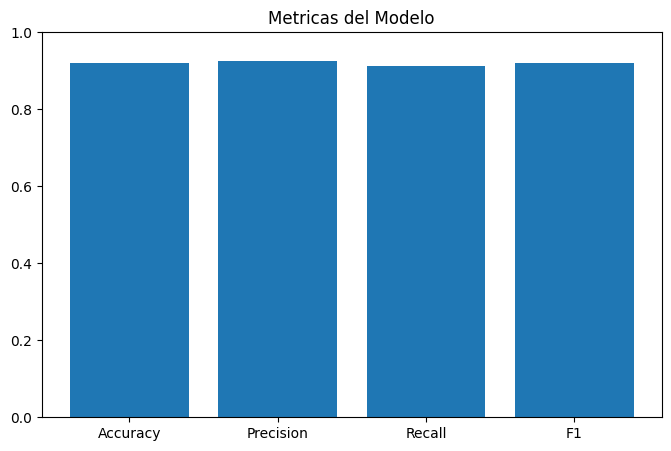

In [ ]:
import matplotlib.pyplot as plt

metricas = [
    accuracy,
    precision,
    recall,
    f1
]

nombres = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

plt.figure(figsize=(8,5))
plt.bar(
    nombres,
    metricas
)

plt.ylim(0,1)
plt.title("Metricas del Modelo")
plt.show()